In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://books.toscrape.com/catalogue/page-{}.html"
product_base = "https://books.toscrape.com/catalogue/"
headers = {'User-Agent': 'Mozilla/5.0'}
all_books = []

# Scrape first 6 pages (~120 books)
for page in range(1, 7):
    url = base_url.format(page)
    response = requests.get(url, headers=headers)
    print(f"Fetching page {page} - Status: {response.status_code}")
    soup = BeautifulSoup(response.text, 'html.parser')
    books = soup.find_all('article', class_='product_pod')
    print(f"  Found {len(books)} books on page {page}")

    for book in books:
        try:
            title = book.h3.a['title']

            # Clean price string
            price_raw = book.find('p', class_='price_color').text
            price_cl = price_raw.encode('ascii', 'ignore').decode().replace('£', '').strip()

            availability = book.find('p', class_='instock availability').text.strip()

            rating_tag = book.find('p', class_='star-rating')
            rating = rating_tag['class'][1] if rating_tag else 'No rating'

            product_url = product_base + book.h3.a['href']
            image_url = "https://books.toscrape.com/" + book.img['src'].replace('../', '')

            # Visit product page for more details
            prod_response = requests.get(product_url, headers=headers)
            prod_soup = BeautifulSoup(prod_response.text, 'html.parser')

            # Extract product info table
            table = prod_soup.find('table', class_='table table-striped')
            rows = table.find_all('tr')
            upc = rows[0].td.text

            # Safer stock extraction
            stock = next((row.td.text for row in rows if row.th.text == 'Availability'), 'Unknown')

            # Extract category
            category = prod_soup.find('ul', class_='breadcrumb').find_all('li')[2].text.strip()

            # Extract description
            desc_tag = prod_soup.find('meta', attrs={'name': 'description'})
            description = desc_tag['content'].strip() if desc_tag else 'No description'

            all_books.append({
                'Title': title,
                'Price (£)': float(price_cl),
                'Availability': availability,
                'Rating': rating,
                'Product URL': product_url,
                'Image URL': image_url,
                'UPC': upc,
                'Stock': stock,
                'Category': category,
                'Description': description
            })

            time.sleep(0.5)  # Be polite to the server

        except Exception as e:
            print(f"  Skipping a book due to error: {e}")

# Save to CSV
df = pd.DataFrame(all_books)
df.to_csv('books_detailed.csv', index=False)
print(f"\n✅ Scraping complete. {len(df)} books saved to 'books_detailed.csv'")


Fetching page 1 - Status: 200
  Found 20 books on page 1
Fetching page 2 - Status: 200
  Found 20 books on page 2
Fetching page 3 - Status: 200
  Found 20 books on page 3
Fetching page 4 - Status: 200
  Found 20 books on page 4
Fetching page 5 - Status: 200
  Found 20 books on page 5
Fetching page 6 - Status: 200
  Found 20 books on page 6


In [2]:
import pandas as pd

df = pd.read_csv('books_detailed.csv')
df.head()  # Show first

,Title,Price (£),Availability,Rating,Product URL,Image URL,UPC,Stock,Category,Description
0,A Light in the Attic,51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/media/cache/2c/da/2...,a897fe39b1053632,In stock (22 available),Poetry,It's hard to imagine a world without A Light i...
1,Tipping the Velvet,53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/media/cache/26/0c/2...,90fa61229261140a,In stock (20 available),Historical Fiction,"""Erotic and absorbing...Written with starling ..."
2,Soumission,50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/media/cache/3e/ef/3...,6957f44c3847a760,In stock (20 available),Fiction,"Dans une France assez proche de la nÃ´tre, un ..."
3,Sharp Objects,47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/media/cache/32/51/3...,e00eb4fd7b871a48,In stock (20 available),Mystery,"WICKED above her hipbone, GIRL across her hear..."
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/media/cache/be/a5/b...,4165285e1663650f,In stock (20 available),History,From a renowned historian comes a groundbreaki...


In [3]:
#check for duplicates
duplicates = df.duplicated()
print(f"Duplicates found: {duplicates.sum()}")
df = df.drop_duplicates()


Duplicates found: 0


In [4]:
#Handling missing values
print(df.isnull().sum())
df.fillna('Unknown', inplace=True)  


Title           0
Price (£)       0
Availability    0
Rating          0
Product URL     0
Image URL       0
UPC             0
Stock           0
Category        0
Description     0
dtype: int64


In [5]:
#convert data types
df['Price (£)'] = pd.to_numeric(df['Price (£)'], errors='coerce')
df['Stock'] = pd.to_numeric(df['Stock'], errors='coerce')
print(df.dtypes)



Title            object
Price (£)       float64
Availability     object
Rating           object
Product URL      object
Image URL        object
UPC              object
Stock           float64
Category         object
Description      object
dtype: object


In [6]:
#clean to text column
df['Rating'] = df['Rating'].str.replace('star-rating', '').str.strip()
df['Availability_length'] = df['Availability'].apply(len)
print(df[['Availability', 'Availability_length']].head())



  Availability  Availability_length
0     In stock                    8
1     In stock                    8
2     In stock                    8
3     In stock                    8
4     In stock                    8


In [7]:
#Exploratory data Analysis
print(df['Category'].value_counts())
print(df['Rating'].value_counts())
df.describe()


Category
Sequential Art        21
Nonfiction            14
Default               10
Poetry                 7
Fantasy                6
Fiction                5
Food and Drink         5
Romance                5
Young Adult            5
Add a comment          5
History                4
Music                  3
Thriller               3
Mystery                3
Childrens              3
Science                2
Spirituality           2
Science Fiction        2
Historical Fiction     2
Self Help              2
Philosophy             2
Business               1
Travel                 1
Politics               1
New Adult              1
Art                    1
Contemporary           1
Health                 1
Horror                 1
Religion               1
Name: count, dtype: int64
Rating
Three    26
Two      26
One      25
Four     22
Five     21
Name: count, dtype: int64


,Price (£),Stock,Availability_length
count,120.000000,0.0,120.0
mean,34.848167,NaN,8.0
std,14.319930,NaN,0.0
min,10.160000,NaN,8.0
25%,21.635000,NaN,8.0
50%,34.775000,NaN,8.0
75%,47.967500,NaN,8.0
max,58.110000,NaN,8.0


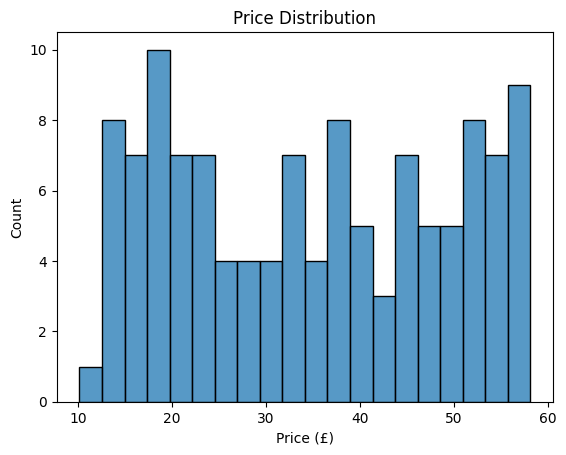

In [8]:
#visualisations
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Price (£)'], bins=20)
plt.title('Price Distribution')
plt.show()


In [9]:
#sql
import pandas as pd
from sqlalchemy import create_engine


In [10]:
df = pd.read_csv('books_detailed.csv')
df.head()



,Title,Price (£),Availability,Rating,Product URL,Image URL,UPC,Stock,Category,Description
0,A Light in the Attic,51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/media/cache/2c/da/2...,a897fe39b1053632,In stock (22 available),Poetry,It's hard to imagine a world without A Light i...
1,Tipping the Velvet,53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/media/cache/26/0c/2...,90fa61229261140a,In stock (20 available),Historical Fiction,"""Erotic and absorbing...Written with starling ..."
2,Soumission,50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/media/cache/3e/ef/3...,6957f44c3847a760,In stock (20 available),Fiction,"Dans une France assez proche de la nÃ´tre, un ..."
3,Sharp Objects,47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/media/cache/32/51/3...,e00eb4fd7b871a48,In stock (20 available),Mystery,"WICKED above her hipbone, GIRL across her hear..."
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/media/cache/be/a5/b...,4165285e1663650f,In stock (20 available),History,From a renowned historian comes a groundbreaki...


In [11]:
#Create SQLite Engine
#This creates a new database file called books.db:
engine = create_engine('sqlite:///books.db')

In [12]:
#save data frame to database
import pandas as pd
import sqlite3

# Load cleaned CSV
df = pd.read_csv('books_detailed.csv')

# Create SQLite connection
conn = sqlite3.connect('books.db')

# Save to database
df.to_sql(name='books', con=conn, index=False, if_exists='replace')

# ✅ Verify using the same connection
df_check = pd.read_sql('SELECT * FROM books LIMIT 5', con=conn)
print(df_check)

# Close connection
conn.close()




                                   Title  Price (£) Availability Rating  \
0                   A Light in the Attic      51.77     In stock  Three   
1                     Tipping the Velvet      53.74     In stock    One   
2                             Soumission      50.10     In stock    One   
3                          Sharp Objects      47.82     In stock   Four   
4  Sapiens: A Brief History of Humankind      54.23     In stock   Five   

                                         Product URL  \
0  https://books.toscrape.com/catalogue/a-light-i...   
1  https://books.toscrape.com/catalogue/tipping-t...   
2  https://books.toscrape.com/catalogue/soumissio...   
3  https://books.toscrape.com/catalogue/sharp-obj...   
4  https://books.toscrape.com/catalogue/sapiens-a...   

                                           Image URL               UPC  \
0  https://books.toscrape.com/media/cache/2c/da/2...  a897fe39b1053632   
1  https://books.toscrape.com/media/cache/26/0c/2...  90fa612292

In [13]:
#check its verified 
import sqlite3
import pandas as pd
conn = sqlite3.connect('books.db')
df_check = pd.read_sql('SELECT * FROM books LIMIT 5', con=conn)
df_check.head()
conn.close()
print(df_check)


                                   Title  Price (£) Availability Rating  \
0                   A Light in the Attic      51.77     In stock  Three   
1                     Tipping the Velvet      53.74     In stock    One   
2                             Soumission      50.10     In stock    One   
3                          Sharp Objects      47.82     In stock   Four   
4  Sapiens: A Brief History of Humankind      54.23     In stock   Five   

                                         Product URL  \
0  https://books.toscrape.com/catalogue/a-light-i...   
1  https://books.toscrape.com/catalogue/tipping-t...   
2  https://books.toscrape.com/catalogue/soumissio...   
3  https://books.toscrape.com/catalogue/sharp-obj...   
4  https://books.toscrape.com/catalogue/sapiens-a...   

                                           Image URL               UPC  \
0  https://books.toscrape.com/media/cache/2c/da/2...  a897fe39b1053632   
1  https://books.toscrape.com/media/cache/26/0c/2...  90fa612292

In [14]:
# Extract numeric value from 'Stock' column
df['Stock'] = df['Stock'].str.extract(r'(\d+)').astype(float)


In [15]:
#unsupervised learning-clustering with k means
#group books based on numeric features likeprice and stock to find clustersof similar books
#choose numeric column for clustering
features = df[['Price (£)', 'Stock']]
#standardise the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)



In [16]:
#apply k-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)



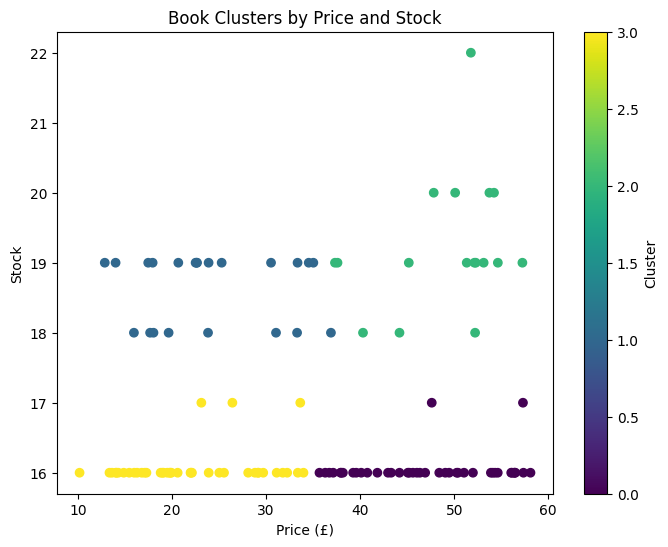

In [17]:
#visualise the clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['Price (£)'], df['Stock'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Price (£)')
plt.ylabel('Stock')
plt.title('Book Clusters by Price and Stock')
plt.colorbar(label='Cluster')
plt.show()


In [18]:

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=50)
plt.title('KMeans Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.colorbar(scatter, label='Cluster Label')
plt.tight_layout()
plt.show()



NameError: name 'X_scaled' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Price (£)'],
    df['Stock'],
    c=df['Cluster'],
    cmap='viridis',
    edgecolor='k',
    s=80
)

# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Add labels and title
plt.xlabel('Price (£)')
plt.ylabel('Stock')
plt.title('Book Clusters by Price and Stock')
plt.tight_layout()
plt.show()


In [ ]:
#analyse cluster characterstics
cluster_summary = df.groupby('Cluster')[['Price (£)', 'Stock']].mean()
print(cluster_summary)


In [ ]:
#Explore categories within clusters
category_distribution = df.groupby('Cluster')['Category'].value_counts(normalize=True)
print(category_distribution)


In [ ]:
#supervisedd learning classification
#target variable is category
category_distribution = df.groupby('Cluster')['Category'].value_counts(normalize=True)
print(category_distribution)
X = df[['Price (£)', 'Stock', 'Cluster']]  # Features
y = df['Category']                         # Target label



In [ ]:
#Encode target label ,convert fiction and everything into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
#split data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [ ]:
#train a random forest classifier
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


In [ ]:

from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)

# Get only the labels present in y_test
present_labels = sorted(set(y_test))

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, labels=present_labels, target_names=le.classes_[present_labels]))



In [ ]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))




In [ ]:
#svc 
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svc))


In [ ]:
#xg boost
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)

# Get only the labels present in y_test and y_pred
present_labels = sorted(set(y_test) | set(y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, labels=present_labels, target_names=le.classes_[present_labels]))


In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


In [ ]:
#hyperparameter tuning for knn
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier 



In [ ]:
#define parameter search
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [ ]:
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Then split X_scaled into train/test


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, knn.predict(X_test)))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Define predictions for working models
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = clf.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_knn = knn.predict(X_test)

# Create model dictionary
models = {
    'Logistic': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svc,
    'KNN': y_pred_knn
}

# Calculate F1 scores using present labels only
f1_scores = {}
for name, pred in models.items():
    labels_union = sorted(set(y_test) | set(pred))
    score = f1_score(y_test, pred, labels=labels_union, average='macro')
    f1_scores[name] = score

# Plot F1 score comparison
plt.figure(figsize=(10, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color='skyblue')
plt.ylabel('F1 Score (Macro)')
plt.title('Model Comparison – F1 Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Get predictions for each model
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = clf.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_knn = knn.predict(X_test)

# Store predictions in a dictionary
models = {
    'Logistic': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svc,
    'KNN': y_pred_knn
}

# Calculate accuracy for each model
accuracies = {name: accuracy_score(y_test, pred) for name, pred in models.items()}

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color='lightgreen')
plt.ylabel('Accuracy')
plt.title('Model Comparison – Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform'],
    'metric': ['manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(X_train, y_train)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Filter for metric='manhattan' and weights='uniform'
filtered = results[(results['param_metric'] == 'manhattan') & (results['param_weights'] == 'uniform')]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(filtered['param_n_neighbors'], filtered['mean_test_score'], marker='o', color='purple')
plt.title('KNN Hyperparameter Tuning – Accuracy vs. n_neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True)
plt.xticks(filtered['param_n_neighbors'])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
